# Assignment 1 – Disaster Management (Spring 2026)
## Flood Extent Mapping and Risk Assessment
### Study Event: Assam Floods (Monsoon 2022) | Study Area: All Districts of Assam, India

---

## 📦 Install & Import All Required Libraries

In [1]:
# ── Install all required packages ──────────────────────────────────────────────
import subprocess
import sys

packages = [
    "earthengine-api",
    "geemap",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "folium",
    "geopandas",
    "shapely",
    "scipy",
    "ipywidgets",
    "branca",
    "rasterio",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed successfully.")


All packages installed successfully.


In [2]:
# ── Core imports & configuration ───────────────────────────────────────────────
import os
import json
import warnings

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium

from IPython.display import Image as IPImage

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
sns.set_style("whitegrid")

# ── Study configuration (matched to reference solution) ───────────────────────
PROJECT      = 'disaster-490916'
PRE_START    = '2022-05-01'
PRE_END      = '2022-05-31'
POST_START   = '2022-06-20'
POST_END     = '2022-07-20'
THRESHOLD_DB = -16

os.makedirs('outputs', exist_ok=True)

print("All libraries imported successfully.")
print(f"Output directory ready: {os.path.abspath('outputs')}")


All libraries imported successfully.
Output directory ready: /home/chirag/Desktop/SEM 8/Disaster/DisasterProject/Wildfire-Spread-Prediction/Assignment/outputs


---
## Task 1 – GEE Setup and Data Loading (15 Marks)

### 1.1 Authenticate and Initialise Google Earth Engine

In [3]:
# Authenticate and initialise GEE
try:
    ee.Initialize(project=PROJECT)
    print(f"GEE initialised successfully (using cached credentials). Project: {PROJECT}")
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT)
    print(f"GEE authenticated and initialised. Project: {PROJECT}")

print(f"Earth Engine Python API version: {ee.__version__}")


GEE initialised successfully (using cached credentials). Project: disaster-490916
Earth Engine Python API version: 1.7.18


### 1.2 Define Assam Area of Interest (AOI) Using FAO GAUL

In [4]:
# ── State boundary (Level-1) ───────────────────────────────────────────────────
gaul_l1     = ee.FeatureCollection('FAO/GAUL/2015/level1')
assam_state = gaul_l1.filter(ee.Filter.eq('ADM1_NAME', 'Assam'))
assam_aoi   = assam_state.geometry()

# ── District boundaries (Level-2) ─────────────────────────────────────────────
gaul_l2         = ee.FeatureCollection('FAO/GAUL/2015/level2')
assam_districts = gaul_l2.filter(ee.Filter.eq('ADM1_NAME', 'Assam'))

n_districts = assam_districts.size().getInfo()
print(f"Assam AOI loaded. Total districts found: {n_districts}")
print(f"Assam bounds: {assam_aoi.bounds().getInfo()['coordinates']}")

# Quick verification map
Map = geemap.Map(center=[26.2, 92.9], zoom=7)
Map.addLayer(assam_districts, {'color': '0000FF'}, 'Assam Districts')
Map.addLayer(assam_state, {'color': 'FF0000'}, 'Assam State Boundary')
Map.addLayerControl()
Map


Assam AOI loaded. Total districts found: 23
Assam bounds: [[[89.6948399758636, 24.13475067990437], [96.02091316406238, 24.13475067990437], [96.02091316406238, 27.977372102348333], [89.6948399758636, 27.977372102348333], [89.6948399758636, 24.13475067990437]]]


Map(center=[26.2, 92.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

### 1.3 Load Sentinel-1 SAR Data for Pre-flood and Post-flood Periods

In [5]:
# ── Date windows matched to the reference solution ─────────────────────────────
# Pre-flood : May 2022 (baseline conditions before the main flood pulse)
# Post-flood: 20 June 2022 to 20 July 2022 (peak inundation window)

def load_s1_composite(start, end):
    """Return the mean Sentinel-1 VV composite over Assam for a date window."""
    collection = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterBounds(assam_aoi)
          .filterDate(start, end)
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .select('VV')
    )

    count = collection.size().getInfo()
    print(f"[{start} → {end}] Sentinel-1 scenes found: {count}")

    return collection.mean().clip(assam_aoi)

print("Loading pre-flood composite...")
vv_pre = load_s1_composite(PRE_START, PRE_END)

print("Loading post-flood composite...")
vv_post = load_s1_composite(POST_START, POST_END)

print("\nSentinel-1 mean composites ready.")


Loading pre-flood composite...
[2022-05-01 → 2022-05-31] Sentinel-1 scenes found: 48
Loading post-flood composite...
[2022-06-20 → 2022-07-20] Sentinel-1 scenes found: 40

Sentinel-1 mean composites ready.


### 1.4 Generate Mean VV Composites

In [6]:
# Mean composites over the respective time windows
sar_vis = {'min': -25, 'max': 0, 'palette': ['black', 'white']}

Map2 = geemap.Map(center=[26.2, 92.9], zoom=7)
Map2.addLayer(vv_pre, sar_vis, 'VV Pre-flood (mean composite)')
Map2.addLayer(vv_post, sar_vis, 'VV Post-flood (mean composite)')
Map2.addLayer(assam_districts, {'color': 'FFFFFF'}, 'Districts', opacity=0.4)
Map2.addLayerControl()
Map2


Map(center=[26.2, 92.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

### 1.5 Why Mean Compositing?

**Discussion:**  
SAR backscatter is highly sensitive to local surface roughness, transient soil moisture, and incidence-angle variation. A single Sentinel-1 acquisition may contain speckle noise, orbital coverage gaps, or short-lived non-flood signals such as rain-wetted croplands.  
**Mean compositing** over a multi-week window averages out these stochastic effects to produce a spatially continuous, temporally representative image. This improves the signal-to-noise ratio: the pre-flood baseline then accurately reflects stable dry-land backscatter, while the post-flood composite captures the persistent flooded signal rather than a transient one-day artefact. It also fills any swath gaps by combining multiple orbital passes.

---
## Task 2 – Flood Detection and Mask Generation (20 Marks)

### 2.1 Apply Backscatter Threshold to Detect Water in Post-flood Imagery

In [7]:
# Pixels with very low VV backscatter are interpreted as open water
# This follows the same threshold-based flood detection logic as the reference
flood_raw = vv_post.lt(THRESHOLD_DB).rename('flood_raw')

raw_area = flood_raw.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=assam_aoi,
    scale=30,
    maxPixels=1e10
).getInfo()

print(f"Raw detected water area (post-flood threshold only): {raw_area.get('flood_raw', 0) / 1e6:.2f} km²")


Raw detected water area (post-flood threshold only): 7511.41 km²


### 2.2 Remove Permanent Water Bodies Using Pre-flood Data

In [8]:
# Permanent water removal is matched to the reference notebook:
# pixels already classified as water in the pre-flood SAR composite are removed
pre_water     = vv_pre.lt(THRESHOLD_DB).rename('pre_water')
flood_no_perm = flood_raw.And(pre_water.Not()).rename('flood_no_perm')

area_no_perm = flood_no_perm.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=assam_aoi,
    scale=30,
    maxPixels=1e10
).getInfo()

print(f"Flood area after removing permanent water: {area_no_perm.get('flood_no_perm', 0) / 1e6:.2f} km²")


Flood area after removing permanent water: 2974.80 km²


### 2.3 Apply Morphological Filtering to Reduce Noise

In [9]:
# Morphological filtering to reduce SAR speckle noise
# Reference-equivalent cleanup: focal_min(1 px) followed by focal_max(2 px)
flood_final = (
    flood_no_perm
      .focal_min(radius=1, kernelType='circle', units='pixels')
      .focal_max(radius=2, kernelType='circle', units='pixels')
      .rename('flood_final')
)

result = flood_final.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=assam_aoi,
    scale=30,
    maxPixels=1e10
).getInfo()

print("Flood mask derived successfully.")
print(f"Threshold used: VV < {THRESHOLD_DB} dB")
print("Morphological filter: focal_min(1 px) → focal_max(2 px)")
print(f"Final flood area (after filtering): {result.get('flood_final', 0) / 1e6:.2f} km²")


Flood mask derived successfully.
Threshold used: VV < -16 dB
Morphological filter: focal_min(1 px) → focal_max(2 px)
Final flood area (after filtering): 2769.69 km²


### 2.4 Interactive Flood Visualisation Map

In [10]:
Map3 = geemap.Map(center=[26.2, 92.0], zoom=7)
Map3.centerObject(assam_aoi, zoom=7)

sar_vis = {'min': -25, 'max': 0, 'palette': ['black', 'white']}

Map3.addLayer(vv_pre, sar_vis, 'Pre-flood SAR (VV)', False)
Map3.addLayer(vv_post, sar_vis, 'Post-flood SAR (VV)', False)
Map3.addLayer(
    flood_final.selfMask(),
    {'palette': ['#1565c0']},
    'Flood Extent (Sentinel-1)',
    True,
    0.7
)
Map3.addLayer(
    assam_districts.style(color='white', fillColor='00000000', width=1.5),
    {},
    'Assam Districts'
)
Map3.addLayerControl()
Map3


Map(center=[26.352060685710303, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

### 2.5 Limitations of SAR-based Flood Detection

**Discussion:**

1. **Urban double-bounce**: Dense buildings produce strong double-bounce returns, inflating backscatter and masking inundation beneath structures — leading to flood under-detection in towns.
2. **Vegetated floodplains**: Flooded paddy fields or forest understories exhibit volume scattering, raising backscatter above the water threshold and causing missed detections.
3. **Fixed-threshold sensitivity**: A single global threshold (–16 dB) does not account for incidence-angle gradients across the SAR swath. Adaptive thresholding (e.g., Otsu's method per district) would improve accuracy.
4. **Wind-roughened water**: Strong winds roughen the flood surface, increasing backscatter and mimicking non-water returns — reducing detection rates on windy acquisition days.
5. **Temporal averaging trade-off**: Mean compositing over several weeks may average out short-duration peak-flood pulses, slightly under-representing maximum inundation.
6. **Terrain-induced distortions**: SAR layover and shadow in Assam's hilly fringes (Karbi Anglong, Dima Hasao) create geometric artefacts that produce both false positives and missed detections.

---
## Task 3 – Population Impact Analysis (20 Marks)

### 3.1 Load GHSL Population Data and Mask by Flood Extent

In [11]:
# GHSL 2020 population layer (100 m) matched to the reference solution
ghsl_pop = (
    ee.ImageCollection('JRC/GHSL/P2023A/GHS_POP')
      .filterDate('2020-01-01', '2020-12-31')
      .select('population_count')
      .mosaic()
      .clip(assam_aoi)
)

# Mask population to flooded pixels only
pop_flooded = ghsl_pop.updateMask(flood_final).rename('pop_flooded')

total = pop_flooded.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=assam_aoi,
    scale=100,
    maxPixels=1e10
).getInfo()

print(f"Total estimated population within flood zone: {int(total.get('pop_flooded', 0) or 0):,}")


Total estimated population within flood zone: 127,072


### 3.2 District-level Statistics via reduceRegions()

In [12]:
# District statistics are computed in three separate steps, matching the reference
# ── Flooded area per district (km²) ────────────────────────────────────────────
flood_area_img = flood_final.multiply(ee.Image.pixelArea()).divide(1e6)

flood_stats = flood_area_img.reduceRegions(
    collection=assam_districts,
    reducer=ee.Reducer.sum(),
    scale=30
)

# ── Population affected per district ───────────────────────────────────────────
pop_stats = ghsl_pop.updateMask(flood_final).reduceRegions(
    collection=assam_districts,
    reducer=ee.Reducer.sum(),
    scale=100
)

# ── Total district area per district (km²) ─────────────────────────────────────
district_area_img = ee.Image.pixelArea().divide(1e6)
total_stats = district_area_img.reduceRegions(
    collection=assam_districts,
    reducer=ee.Reducer.sum(),
    scale=100
)

print("Fetching district statistics from GEE...")

flood_feats = flood_stats.getInfo()['features']
pop_feats   = pop_stats.getInfo()['features']
area_feats  = total_stats.getInfo()['features']

def features_to_df(features, value_name):
    rows = []
    for feature in features:
        props = feature['properties']
        rows.append({
            'district': props.get('ADM2_NAME', 'Unknown'),
            value_name: props.get('sum', 0) or 0
        })
    return pd.DataFrame(rows)

df_flood = features_to_df(flood_feats, 'flooded_km2')
df_pop   = features_to_df(pop_feats,   'pop_affected')
df_area  = features_to_df(area_feats,  'total_area_km2')

df = (
    df_flood
      .merge(df_pop, on='district')
      .merge(df_area, on='district')
)

df['flood_fraction'] = (df['flooded_km2'] / df['total_area_km2']).clip(0, 1)
df['pop_affected']   = df['pop_affected'].fillna(0).astype(int)
df = df.sort_values('flooded_km2', ascending=False).reset_index(drop=True)

print(f"\n{'=' * 65}")
print(f"  {'District':<20} {'Flooded km²':>12} {'Flood %':>9} {'Pop Affected':>14}")
print(f"  {'─' * 62}")
for _, row in df.iterrows():
    print(
        f"  {row['district']:<20} {row['flooded_km2']:>12.1f} "
        f"{row['flood_fraction'] * 100:>8.1f}% {row['pop_affected']:>14,}"
    )
print(f"{'=' * 65}")
print(f"  TOTAL flooded area : {df['flooded_km2'].sum():,.1f} km²")
print(f"  TOTAL pop affected : {df['pop_affected'].sum():,}")


Fetching district statistics from GEE...

  District              Flooded km²   Flood %   Pop Affected
  ──────────────────────────────────────────────────────────────
  Marigaon                    352.4     22.7%         22,466
  Nagaon                      337.5      8.5%         11,123
  Barpeta                     281.7      8.7%         13,524
  Dhuburi                     233.3      8.3%         18,720
  Kamrup                      196.3      4.5%          8,671
  Cachar                      168.3      4.4%         19,677
  Sonitpur                    165.0      3.5%          1,107
  Dibrugarh                   162.1      4.8%            456
  Karimganj                   142.0      7.7%         16,599
  Darrang                     128.8      3.8%          2,278
  Goalpara                    108.7      5.7%          2,915
  Bongaigaon                   72.3      3.1%          2,335
  Dhemaji                      67.4      2.7%            135
  Golaghat                     66.4    

### 3.3 Structured Table – Districts Sorted by Severity (Affected Population)

In [13]:
df_sorted = df.copy()

# Save the district-level results with the same filename used in the reference
df_sorted.to_csv('outputs/flood_risk_table.csv', index=False)
print("[✓] Saved outputs/flood_risk_table.csv")

display_df = df_sorted.copy()
display_df['pop_affected']   = display_df['pop_affected'].map(lambda x: f"{x:,}")
display_df['flooded_km2']    = display_df['flooded_km2'].map(lambda x: f"{x:.2f}")
display_df['total_area_km2'] = display_df['total_area_km2'].map(lambda x: f"{x:.2f}")
display_df['flood_fraction'] = display_df['flood_fraction'].map(lambda x: f"{x:.4f}")
display_df.rename(columns={
    'district': 'District',
    'flooded_km2': 'Flooded Area (km²)',
    'pop_affected': 'Affected Population',
    'total_area_km2': 'District Area (km²)',
    'flood_fraction': 'Flood Fraction'
}, inplace=True)

display_df


[✓] Saved outputs/flood_risk_table.csv


,District,Flooded Area (km²),Affected Population,District Area (km²),Flood Fraction
0,Marigaon,352.42,"22,466",1553.62,0.2268
1,Nagaon,337.46,"11,123",3989.93,0.0846
2,Barpeta,281.75,"13,524",3247.66,0.0868
3,Dhuburi,233.30,"18,720",2826.44,0.0825
4,Kamrup,196.33,"8,671",4340.39,0.0452
5,Cachar,168.33,"19,677",3798.22,0.0443
6,Sonitpur,165.00,"1,107",4667.87,0.0353
7,Dibrugarh,162.12,456,3391.84,0.0478
8,Karimganj,141.98,"16,599",1852.68,0.0766
9,Darrang,128.84,"2,278",3420.79,0.0377


### 3.4 Visualise Affected Population

In [14]:
# Reference-style interactive map with flood extent, population impact, and districts
Map4 = geemap.Map(center=[26.2, 92.0], zoom=7)
Map4.centerObject(assam_aoi, zoom=7)

sar_vis = {'min': -25, 'max': 0, 'palette': ['black', 'white']}
pop_vis = {
    'min': 0,
    'max': 400,
    'palette': ['#ffffb2', '#fecc5c', '#fd8d3c', '#f03b20', '#bd0026']
}

Map4.addLayer(vv_pre, sar_vis, 'Pre-flood SAR (VV)', False)
Map4.addLayer(vv_post, sar_vis, 'Post-flood SAR (VV)', False)
Map4.addLayer(
    flood_final.selfMask(),
    {'palette': ['#1565c0']},
    'Flood Extent (Sentinel-1)',
    True,
    0.7
)
Map4.addLayer(
    pop_flooded,
    pop_vis,
    'Population Affected (GHSL)',
    True,
    0.8
)
Map4.addLayer(
    assam_districts.style(color='white', fillColor='00000000', width=1.5),
    {},
    'Assam Districts'
)
Map4.add_colorbar(pop_vis, label='Population per pixel (GHSL 2020)')
Map4.addLayerControl()

# Static flood thumbnail, matching the reference output
thumb_url = flood_final.selfMask().clip(assam_aoi).getThumbURL({
    'min': 0,
    'max': 1,
    'palette': ['#1565c0'],
    'dimensions': 1024,
    'region': assam_aoi,
    'format': 'png'
})

print('Flood extent thumbnail URL:')
print(thumb_url)

display(IPImage(url=thumb_url, width=700))
Map4


Flood extent thumbnail URL:
https://earthengine.googleapis.com/v1/projects/disaster-490916/thumbnails/4446fa70261e0278e2c10c1a301ff8e5-fafaeb2b316df1cf2fccf37a87636f19:getPixels


Map(center=[26.352060685710285, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

---
## Task 4 – Flood Risk Index and Mapping (25 Marks)

### 4.1 Normalise All Components and Compute FRI

In [15]:
def min_max_norm(series):
    """Min-max normalise a pandas Series to [0, 1]."""
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-9)

df_fri = df.copy()

# Reference-equivalent risk components
df_fri['pop_density']       = df_fri['pop_affected'] / df_fri['total_area_km2'].clip(lower=1)
df_fri['idx_exposure']      = min_max_norm(df_fri['flood_fraction'])
df_fri['idx_vulnerability'] = min_max_norm(df_fri['pop_density'])
df_fri['idx_severity']      = min_max_norm(df_fri['flooded_km2'])

W_EXP, W_VUL, W_SEV = 0.40, 0.35, 0.25
df_fri['flood_risk_index'] = (
    W_EXP * df_fri['idx_exposure'] +
    W_VUL * df_fri['idx_vulnerability'] +
    W_SEV * df_fri['idx_severity']
)

RISK_COLORS = {
    'Critical': '#d32f2f',
    'High': '#f57c00',
    'Moderate': '#fbc02d',
    'Low': '#388e3c'
}

def classify_risk(fri):
    if fri >= 0.70:
        return 'Critical'
    if fri >= 0.50:
        return 'High'
    if fri >= 0.30:
        return 'Moderate'
    return 'Low'

df_fri['risk_class'] = df_fri['flood_risk_index'].apply(classify_risk)
df_fri['fri_rounded'] = df_fri['flood_risk_index'].round(3)
df_fri = df_fri.sort_values('flood_risk_index', ascending=False).reset_index(drop=True)

summary = (
    df_fri.groupby('risk_class')
          .agg(
              districts=('district', 'count'),
              flooded_km2=('flooded_km2', 'sum'),
              pop_affected=('pop_affected', 'sum')
          )
          .reset_index()
)

print("Flood Risk Index computed.\n")
print("  ── Risk Class Summary ──────────────────────────────────")
print(f"  {'Class':<12} {'Districts':>10} {'Flooded km²':>12} {'Pop Affected':>14}")
print(f"  {'─' * 52}")
for _, row in summary.iterrows():
    print(
        f"  {row['risk_class']:<12} {row['districts']:>10} "
        f"{row['flooded_km2']:>12.1f} {row['pop_affected']:>14,}"
    )

df_fri.to_csv('outputs/flood_risk_table.csv', index=False)
print("\n[✓] Saved outputs/flood_risk_table.csv")
df_fri.head(10)


Flood Risk Index computed.

  ── Risk Class Summary ──────────────────────────────────
  Class         Districts  Flooded km²   Pop Affected
  ────────────────────────────────────────────────────
  Critical              1        352.4         22,466
  Low                  17       1254.4         24,951
  Moderate              5       1162.8         79,643

[✓] Saved outputs/flood_risk_table.csv


,district,flooded_km2,pop_affected,total_area_km2,flood_fraction,pop_density,idx_exposure,idx_vulnerability,idx_severity,flood_risk_index,risk_class,fri_rounded
0,Marigaon,352.416819,22466,1553.620242,0.226836,14.460419,1.000000,1.000000,1.000000,1.000000,Critical,1.000
1,Dhuburi,233.303226,18720,2826.437599,0.082543,6.623178,0.363267,0.458021,0.660961,0.470854,Moderate,0.471
2,Nagaon,337.460338,11123,3989.932933,0.084578,2.787766,0.372245,0.192786,0.957429,0.455730,Moderate,0.456
3,Barpeta,281.748024,13524,3247.658501,0.086754,4.164231,0.381849,0.287974,0.798852,0.453244,Moderate,0.453
4,Karimganj,141.977779,16599,1852.683966,0.076634,8.959434,0.337188,0.619583,0.401017,0.451984,Moderate,0.452
5,Cachar,168.330537,19677,3798.222845,0.044318,5.180581,0.194588,0.358259,0.476026,0.322232,Moderate,0.322
6,Kamrup,196.329258,8671,4340.390326,0.045233,1.997747,0.198625,0.138153,0.555720,0.266733,Low,0.267
7,Goalpara,108.735966,2915,1900.963215,0.057200,1.533433,0.251434,0.106043,0.306399,0.214289,Low,0.214
8,Dibrugarh,162.123151,456,3391.839750,0.047798,0.134440,0.209943,0.009297,0.458358,0.201821,Low,0.202
9,Sonitpur,164.997435,1107,4667.874703,0.035347,0.237153,0.155001,0.016400,0.466539,0.184375,Low,0.184


### 4.2 Choropleth Map – FRI by District

In [16]:
# Fetch district geometries and merge with the computed statistics
districts_geojson = assam_districts.getInfo()

gdf = gpd.GeoDataFrame.from_features(districts_geojson['features'], crs='EPSG:4326')
gdf = gdf.rename(columns={'ADM2_NAME': 'district'})

gdf = gdf.merge(
    df_fri[['district', 'flooded_km2', 'flood_fraction', 'pop_affected',
            'flood_risk_index', 'risk_class', 'fri_rounded']],
    on='district',
    how='left'
)

gdf['flood_fraction']   = gdf['flood_fraction'].fillna(0)
gdf['flood_risk_index'] = gdf['flood_risk_index'].fillna(0)
gdf['risk_class']       = gdf['risk_class'].fillna('Low')
gdf['pop_affected']     = gdf['pop_affected'].fillna(0)

print(f"GeoDataFrame ready: {len(gdf)} districts with geometry + statistics")
gdf[['district', 'flooded_km2', 'pop_affected', 'flood_risk_index', 'risk_class']].head()


GeoDataFrame ready: 23 districts with geometry + statistics


,district,flooded_km2,pop_affected,flood_risk_index,risk_class
0,Barpeta,281.748024,13524,0.453244,Moderate
1,Cachar,168.330537,19677,0.322232,Moderate
2,Darrang,128.837140,2278,0.173110,Low
3,Dhuburi,233.303226,18720,0.470854,Moderate
4,Dibrugarh,162.123151,456,0.201821,Low


### 4.3 FRI and Component Comparison Bar Charts

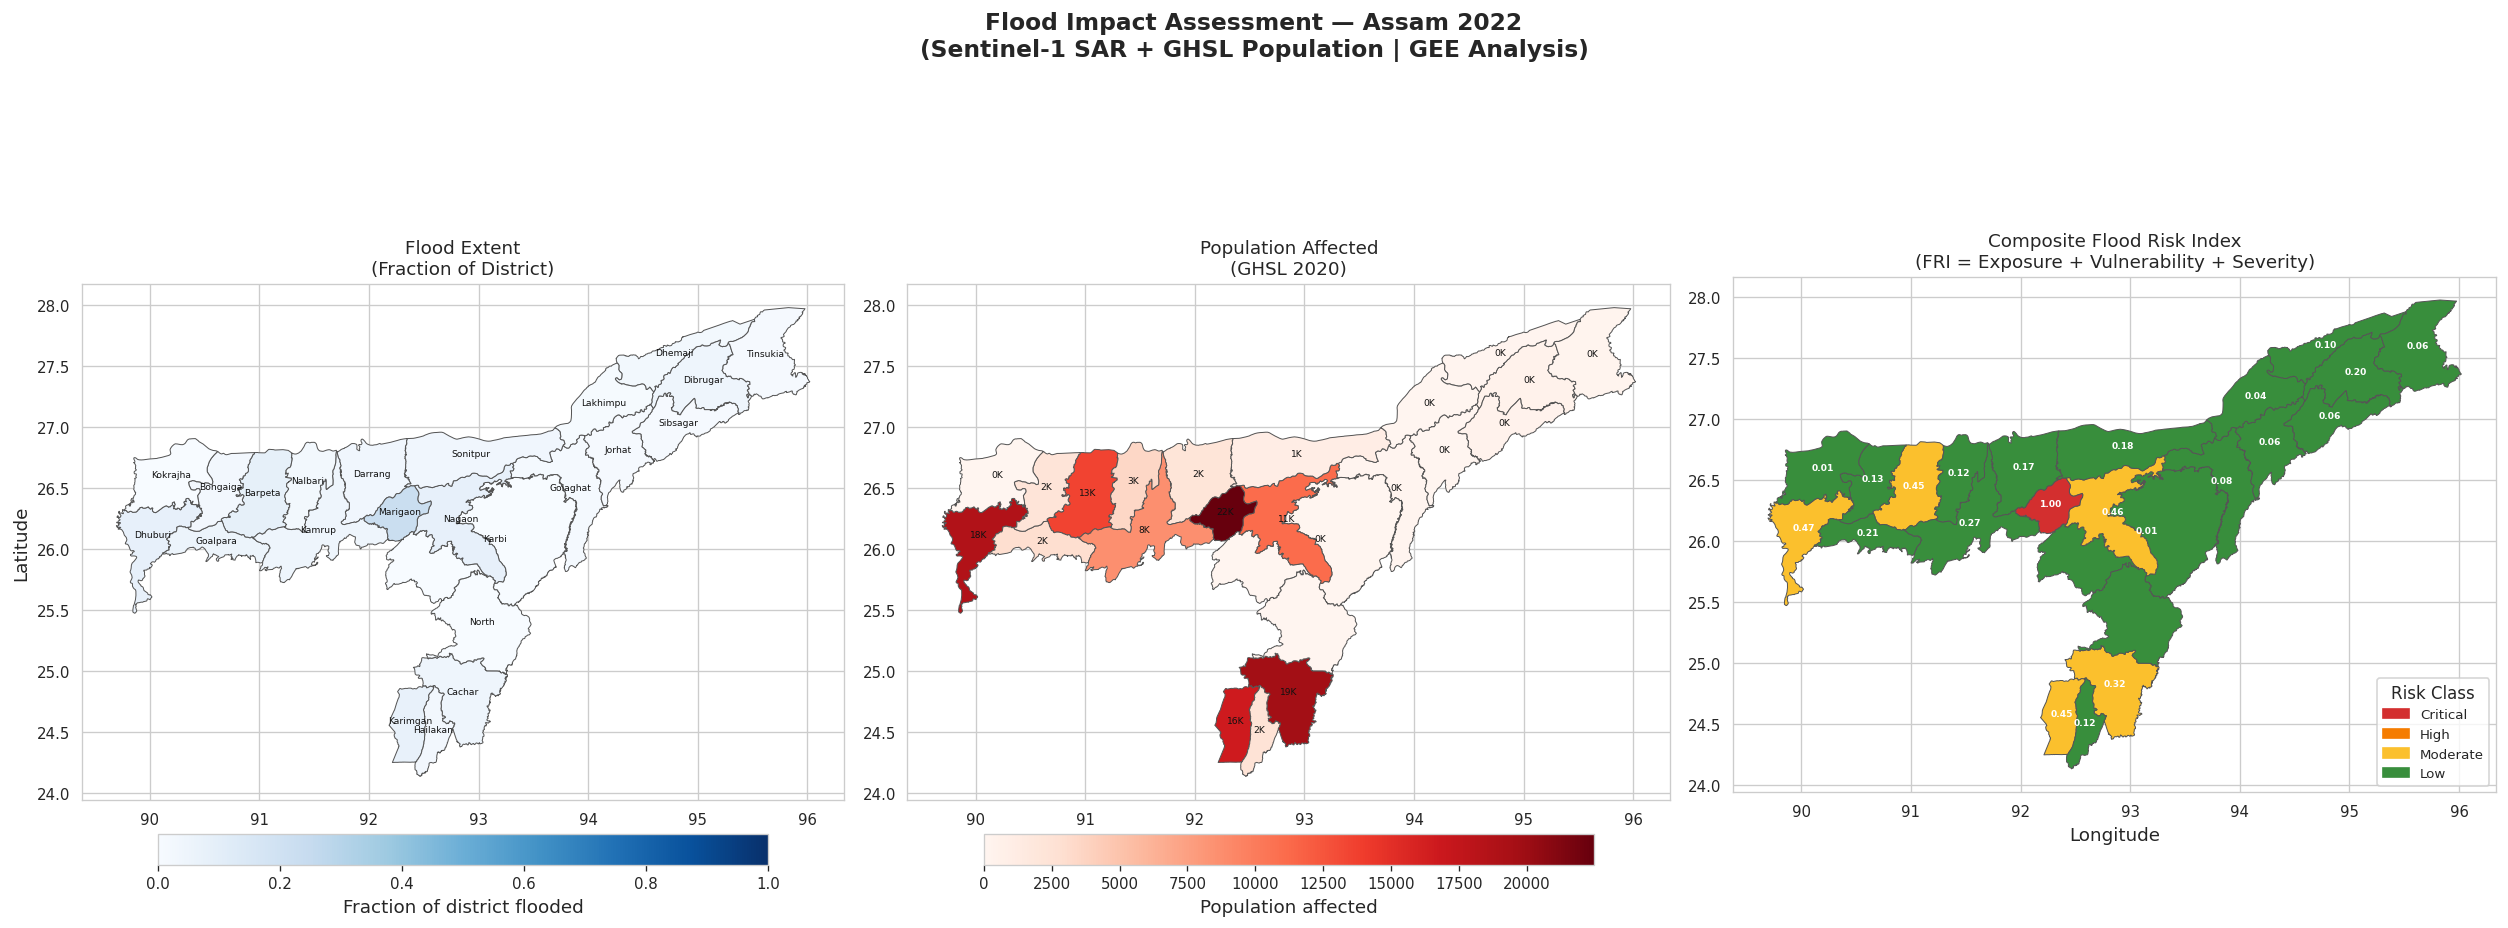

[✓] Saved outputs/fig1_flood_maps.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))
fig.suptitle(
    'Flood Impact Assessment — Assam 2022\n'
    '(Sentinel-1 SAR + GHSL Population | GEE Analysis)',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

# ── Panel 1: Flood fraction ────────────────────────────────────────────────────
ax = axes[0]
gdf.plot(
    ax=ax,
    column='flood_fraction',
    cmap='Blues',
    edgecolor='#555',
    linewidth=0.6,
    legend=True,
    vmin=0,
    vmax=1,
    legend_kwds={
        'label': 'Fraction of district flooded',
        'orientation': 'horizontal',
        'pad': 0.04,
        'shrink': 0.8
    }
)
for _, row in gdf.iterrows():
    if pd.notna(row.geometry):
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(row['district'].split()[0][:8], (cx, cy), ha='center', fontsize=5.5, color='#111')
ax.set_title('Flood Extent\n(Fraction of District)', fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# ── Panel 2: Population affected ───────────────────────────────────────────────
ax = axes[1]
gdf.plot(
    ax=ax,
    column='pop_affected',
    cmap='Reds',
    edgecolor='#555',
    linewidth=0.6,
    legend=True,
    legend_kwds={
        'label': 'Population affected',
        'orientation': 'horizontal',
        'pad': 0.04,
        'shrink': 0.8
    }
)
for _, row in gdf.iterrows():
    if pd.notna(row.geometry) and row['pop_affected'] > 0:
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(f"{int(row['pop_affected']) // 1000}K", (cx, cy), ha='center', fontsize=5.5, color='#111')
ax.set_title('Population Affected\n(GHSL 2020)', fontsize=11)
ax.set_xlabel('Longitude')

# ── Panel 3: Flood risk index ──────────────────────────────────────────────────
ax = axes[2]
panel_colors = gdf['risk_class'].map(RISK_COLORS).fillna('#aaaaaa')
gdf.plot(ax=ax, color=panel_colors, edgecolor='#555', linewidth=0.6)
for _, row in gdf.iterrows():
    if pd.notna(row.geometry) and row['flood_risk_index'] > 0:
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(
            f"{row['flood_risk_index']:.2f}",
            (cx, cy),
            ha='center',
            fontsize=5.5,
            fontweight='bold',
            color='white'
        )
legend_handles = [mpatches.Patch(color=value, label=label) for label, value in RISK_COLORS.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8, title='Risk Class')
ax.set_title('Composite Flood Risk Index\n(FRI = Exposure + Vulnerability + Severity)', fontsize=11)
ax.set_xlabel('Longitude')

plt.tight_layout()
plt.savefig('outputs/fig1_flood_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('[✓] Saved outputs/fig1_flood_maps.png')


### 4.4 Alternative Weightings – Sensitivity Analysis

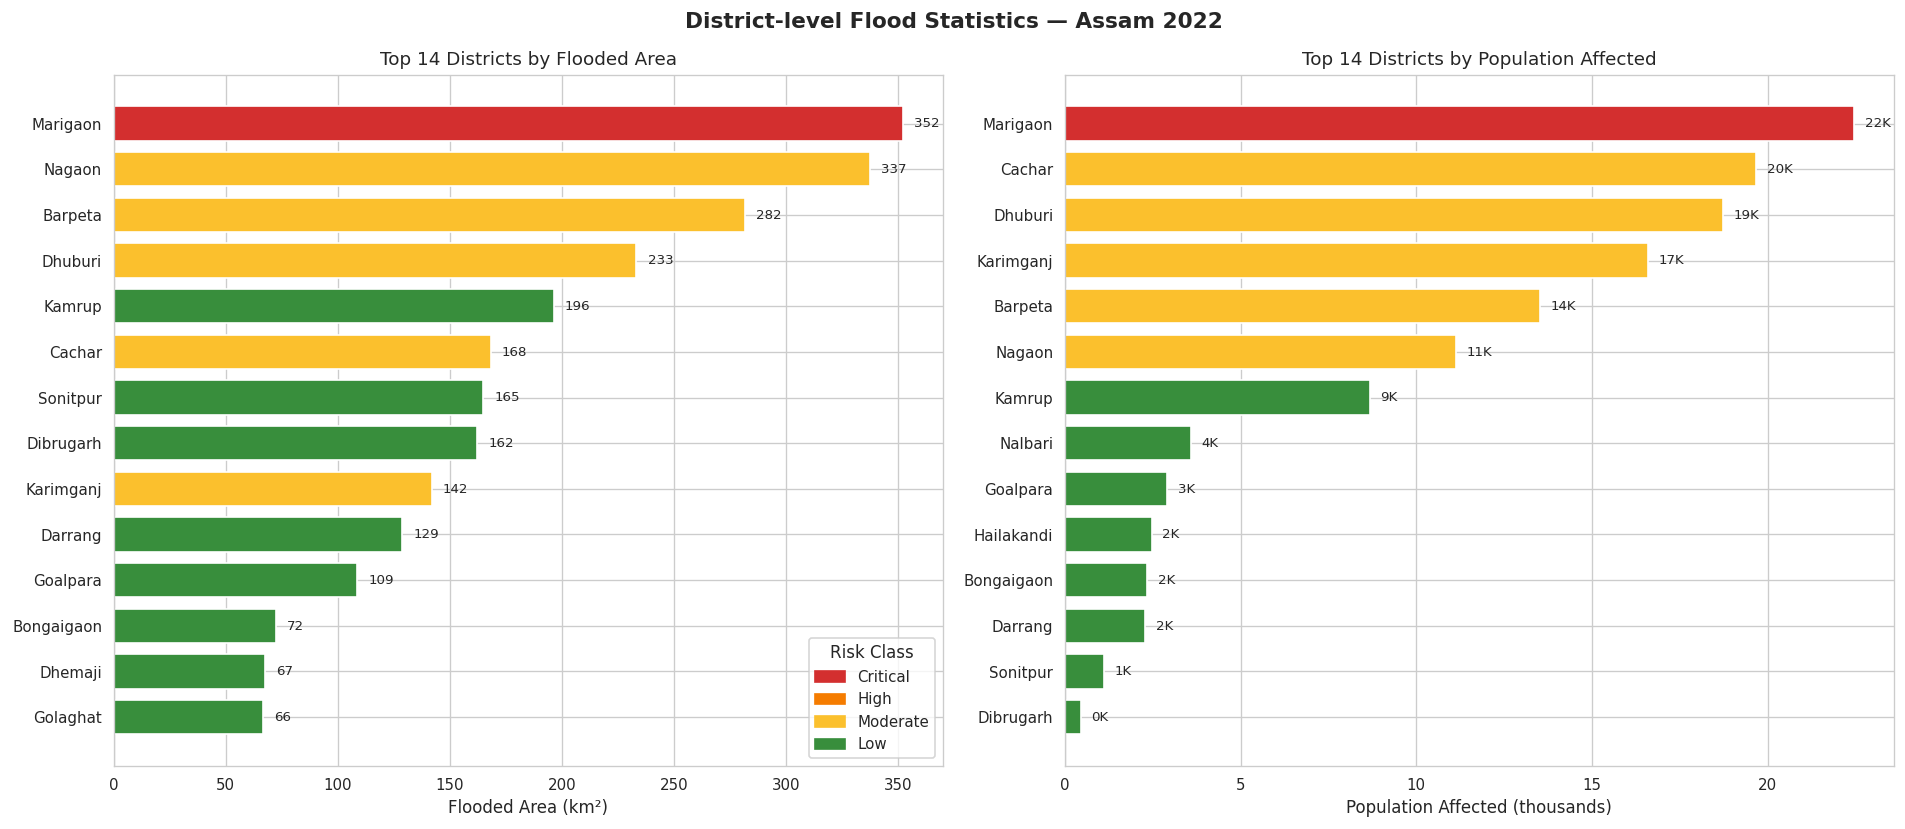

[✓] Saved outputs/fig2_bar_charts.png


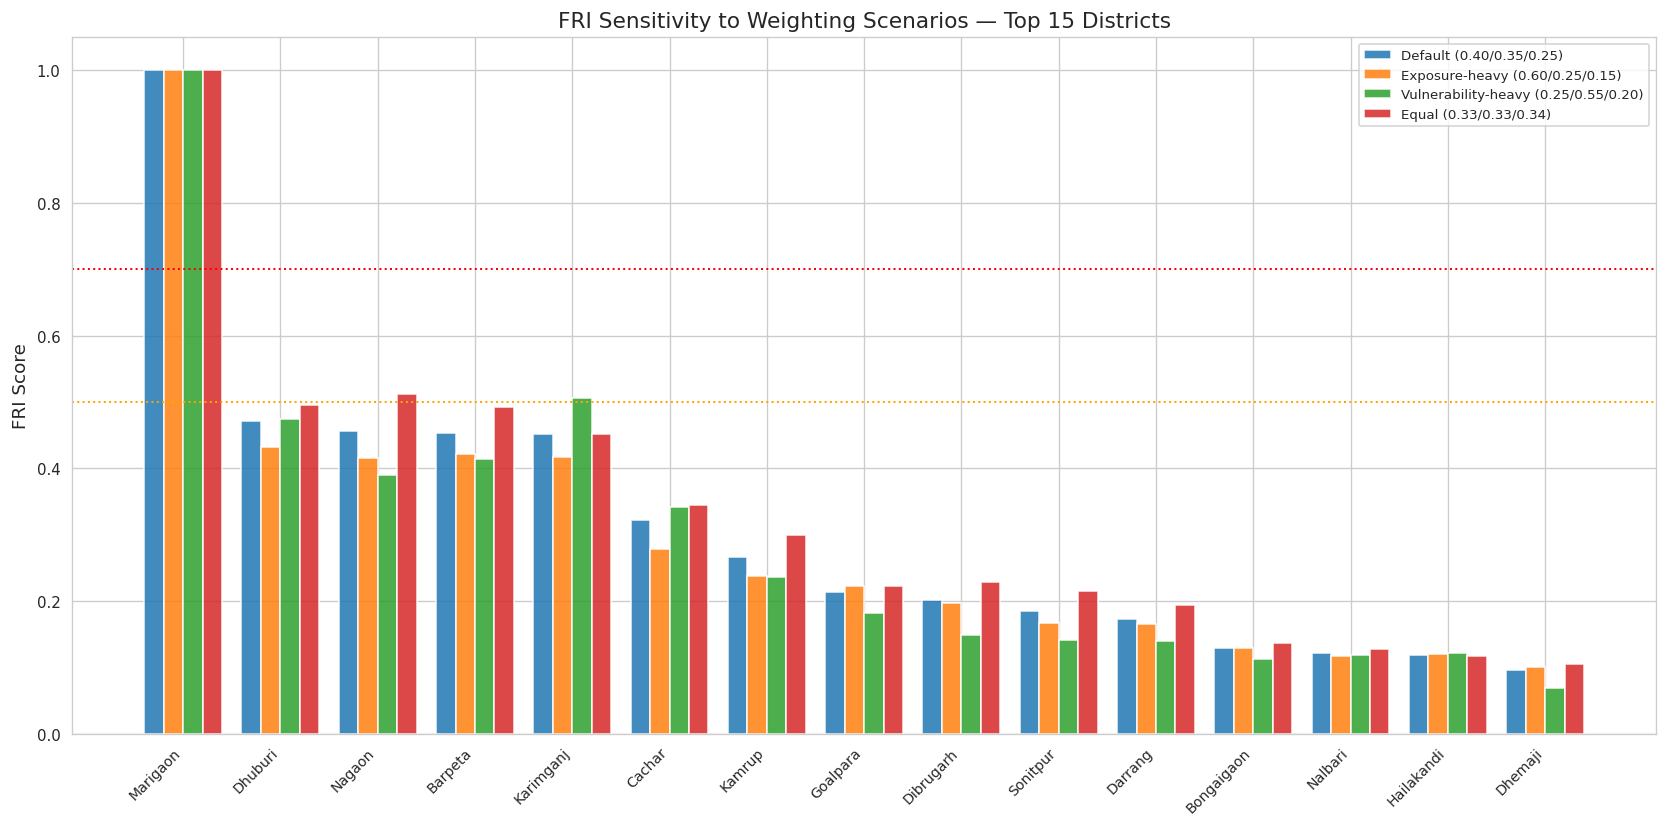


Sensitivity analysis notes:
• Exposure-heavy weighting lifts districts with very large flooded fractions.
• Vulnerability-heavy weighting favours dense districts with high affected population per km².
• Equal weighting produces a more balanced district ranking.


In [18]:
# ── Reference-matched bar charts ───────────────────────────────────────────────
top_n = 14

df_plot = df_fri.nlargest(top_n, 'flooded_km2').sort_values('flooded_km2')
plot_colors = [RISK_COLORS[risk] for risk in df_plot['risk_class']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('District-level Flood Statistics — Assam 2022', fontsize=13, fontweight='bold')

# Flooded area chart
ax = axes[0]
bars = ax.barh(
    df_plot['district'],
    df_plot['flooded_km2'],
    color=plot_colors,
    edgecolor='white',
    height=0.75
)
ax.set_xlabel('Flooded Area (km²)', fontsize=10)
ax.set_title(f'Top {top_n} Districts by Flooded Area', fontsize=11)
for bar, value in zip(bars, df_plot['flooded_km2']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2, f'{value:.0f}', va='center', fontsize=8)
legend_handles = [mpatches.Patch(color=value, label=label) for label, value in RISK_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=9, title='Risk Class')

# Population affected chart
df_pop_sort = df_fri.nlargest(top_n, 'pop_affected').sort_values('pop_affected')
plot_colors_2 = [RISK_COLORS[risk] for risk in df_pop_sort['risk_class']]

ax = axes[1]
bars2 = ax.barh(
    df_pop_sort['district'],
    df_pop_sort['pop_affected'] / 1000,
    color=plot_colors_2,
    edgecolor='white',
    height=0.75
)
ax.set_xlabel('Population Affected (thousands)', fontsize=10)
ax.set_title(f'Top {top_n} Districts by Population Affected', fontsize=11)
for bar, value in zip(bars2, df_pop_sort['pop_affected']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f'{value / 1000:.0f}K', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/fig2_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('[✓] Saved outputs/fig2_bar_charts.png')

# ── Alternative weighting sensitivity analysis (kept in your notebook style) ──
scenarios = {
    'Default (0.40/0.35/0.25)': (0.40, 0.35, 0.25),
    'Exposure-heavy (0.60/0.25/0.15)': (0.60, 0.25, 0.15),
    'Vulnerability-heavy (0.25/0.55/0.20)': (0.25, 0.55, 0.20),
    'Equal (0.33/0.33/0.34)': (0.33, 0.33, 0.34),
}

fri_scenarios = pd.DataFrame({'district': df_fri['district']})
for scenario_name, (w_exp, w_vul, w_sev) in scenarios.items():
    fri_scenarios[scenario_name] = (
        w_exp * df_fri['idx_exposure'].values +
        w_vul * df_fri['idx_vulnerability'].values +
        w_sev * df_fri['idx_severity'].values
    )

top15 = df_fri['district'].head(15).tolist()
fri_top = fri_scenarios[fri_scenarios['district'].isin(top15)].set_index('district')

fig, ax = plt.subplots(figsize=(14, 7))
scenario_width = 0.8 / len(scenarios)
scenario_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (scenario_name, color) in enumerate(zip(scenarios.keys(), scenario_colors)):
    ax.bar(
        np.arange(len(top15)) + i * scenario_width,
        fri_top.loc[top15, scenario_name],
        scenario_width,
        label=scenario_name,
        color=color,
        alpha=0.85
    )

ax.set_xticks(np.arange(len(top15)) + scenario_width * (len(scenarios) - 1) / 2)
ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=8.5)
ax.axhline(0.70, color='red', linestyle=':', lw=1.2)
ax.axhline(0.50, color='orange', linestyle=':', lw=1.2)
ax.set_ylabel('FRI Score')
ax.set_title('FRI Sensitivity to Weighting Scenarios — Top 15 Districts')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print("\nSensitivity analysis notes:")
print("• Exposure-heavy weighting lifts districts with very large flooded fractions.")
print("• Vulnerability-heavy weighting favours dense districts with high affected population per km².")
print("• Equal weighting produces a more balanced district ranking.")


---
## Task 5 – Time-Series Analysis and Policy Brief (20 Marks)

### 5.1 Extract Monthly Water Extent (2019–2022) from JRC

In [19]:
year_months = [(year, month) for year in range(2019, 2023) for month in range(1, 13)]

jrc_monthly = ee.ImageCollection('JRC/GSW1_4/MonthlyHistory')

def get_monthly_water_area(year, month):
    """Return total water area (km²) in Assam for a given year-month."""
    image = (
        jrc_monthly
          .filter(ee.Filter.calendarRange(year, year, 'year'))
          .filter(ee.Filter.calendarRange(month, month, 'month'))
          .first()
    )

    if image is None:
        return None

    water = image.eq(2)
    area = water.multiply(ee.Image.pixelArea()).divide(1e6)
    stats = area.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=assam_aoi,
        scale=100,
        maxPixels=1e10
    )

    value = stats.get('water')
    return value.getInfo() if value is not None else 0

print("Fetching monthly water extent for 2019–2022...")
print("(This makes one GEE request per month.)")

records = []
for year in [2019, 2020, 2021, 2022]:
    for month in range(1, 13):
        try:
            area_km2 = get_monthly_water_area(year, month)
            records.append({
                'year': year,
                'month': month,
                'water_km2': area_km2 if area_km2 else 0
            })
            print(f"  {year}-{month:02d}: {area_km2:.1f} km²")
        except Exception as exc:
            print(f"  {year}-{month:02d}: error ({exc})")
            records.append({
                'year': year,
                'month': month,
                'water_km2': 0
            })

ts_df = pd.DataFrame(records)
ts_df.to_csv('outputs/water_timeseries.csv', index=False)
print("\n[✓] Saved outputs/water_timeseries.csv")
ts_df.head()


Fetching monthly water extent for 2019–2022...
(This makes one GEE request per month.)
  2019-01: 2248.0 km²
  2019-02: 2069.4 km²
  2019-03: 2240.2 km²
  2019-04: 1649.5 km²
  2019-05: 915.9 km²
  2019-06: 3232.7 km²
  2019-07: 5502.8 km²
  2019-08: 5443.1 km²
  2019-09: 4906.3 km²
  2019-10: 3973.1 km²
  2019-11: 3403.6 km²
  2019-12: 2474.7 km²
  2020-01: 2185.0 km²
  2020-02: 2427.3 km²
  2020-03: 2065.1 km²
  2020-04: 2115.4 km²
  2020-05: 2823.0 km²
  2020-06: 1616.9 km²
  2020-07: 2210.5 km²
  2020-08: 2551.8 km²
  2020-09: 4125.6 km²
  2020-10: 6477.8 km²
  2020-11: 3658.5 km²
  2020-12: 2472.0 km²
  2021-01: 2000.0 km²
  2021-02: 2103.1 km²
  2021-03: 2030.0 km²
  2021-04: 2430.9 km²
  2021-05: 1330.0 km²
  2021-06: 1065.9 km²
  2021-07: 3035.7 km²
  2021-08: 2029.3 km²
  2021-09: 5439.1 km²
  2021-10: 3921.7 km²
  2021-11: 3023.9 km²
  2021-12: 2314.0 km²
  2022-01: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-02: error (Image.eq: Parameter 'im

,year,month,water_km2
0,2019,1,2248.021891
1,2019,2,2069.449975
2,2019,3,2240.233776
3,2019,4,1649.479876
4,2019,5,915.923343


### 5.2 Time-Series Plot with Extreme Event Highlights

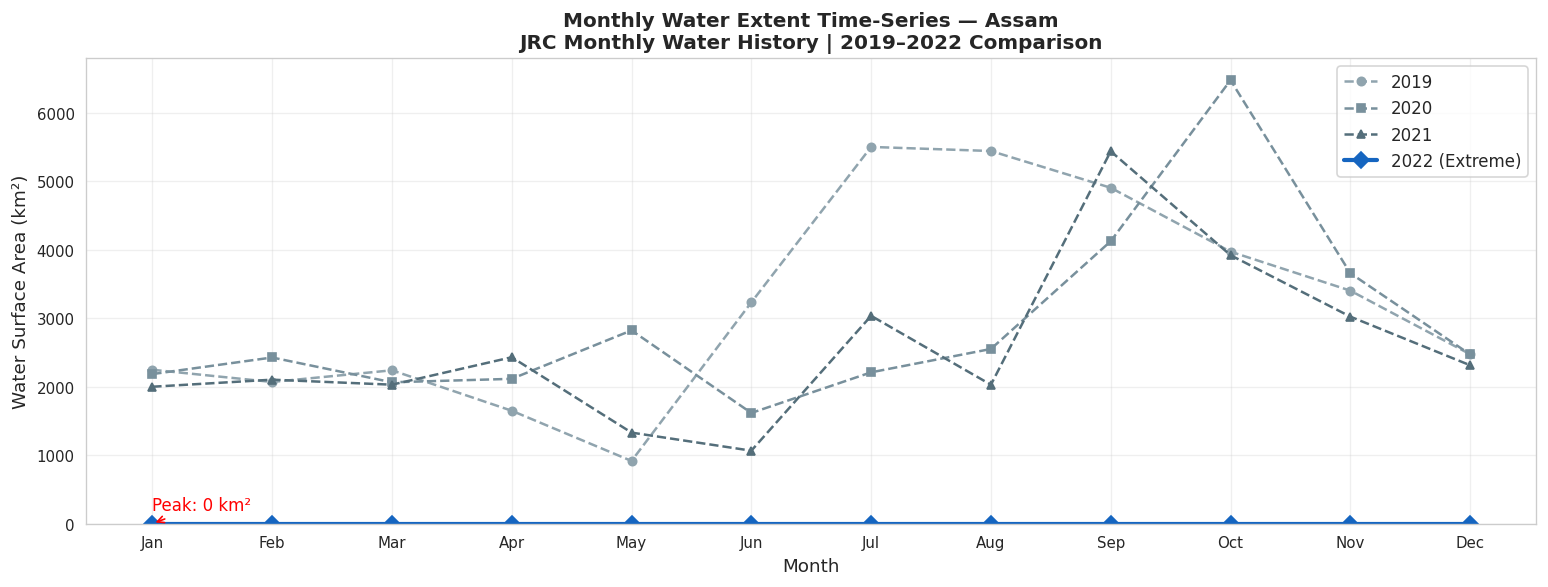

[✓] Saved outputs/fig3_timeseries.png


In [20]:
months_lbl = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

year_colors = {2019: '#90a4ae', 2020: '#78909c', 2021: '#546e7a', 2022: '#1565c0'}
year_styles = {2019: 'o--', 2020: 's--', 2021: '^--', 2022: 'D-'}

fig, ax = plt.subplots(figsize=(13, 5))

for year in [2019, 2020, 2021, 2022]:
    year_df = ts_df[ts_df['year'] == year].sort_values('month')
    values = year_df['water_km2'].values
    line_width = 2.5 if year == 2022 else 1.5
    marker_size = 7 if year == 2022 else 5

    ax.plot(
        months_lbl,
        values,
        year_styles[year],
        color=year_colors[year],
        linewidth=line_width,
        markersize=marker_size,
        label=str(year) + (' (Extreme)' if year == 2022 else '')
    )

ax.fill_between(
    months_lbl,
    ts_df[ts_df['year'] == 2022].sort_values('month')['water_km2'],
    alpha=0.15,
    color='#1565c0'
)

peak_2022 = ts_df[ts_df['year'] == 2022]['water_km2'].max()
peak_idx = ts_df[ts_df['year'] == 2022]['water_km2'].idxmax()
peak_month = months_lbl[int(ts_df.loc[peak_idx, 'month']) - 1]

ax.annotate(
    f'Peak: {peak_2022:.0f} km²',
    xy=(peak_month, peak_2022),
    xytext=(peak_month, peak_2022 + 200),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10,
    color='red'
)

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Water Surface Area (km²)', fontsize=11)
ax.set_title(
    'Monthly Water Extent Time-Series — Assam\n'
    'JRC Monthly Water History | 2019–2022 Comparison',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0)

plt.tight_layout()
plt.savefig('outputs/fig3_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('[✓] Saved outputs/fig3_timeseries.png')


### 5.3 Interactive Multi-Layer Map (Folium)

In [21]:
center_lat = gdf.geometry.centroid.y.mean()
center_lon = gdf.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=7,
    tiles='CartoDB positron'
)

# ── Flood fraction choropleth ──────────────────────────────────────────────────
folium.Choropleth(
    geo_data=gdf.to_json(),
    data=gdf,
    columns=['district', 'flood_fraction'],
    key_on='feature.properties.district',
    fill_color='Blues',
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name='Flood Fraction (0–1)',
    name='Flood Extent (fraction)',
).add_to(m)

# ── Flood risk layer (hidden by default) ───────────────────────────────────────
risk_layer = folium.FeatureGroup(name='Flood Risk Index', show=False)
for _, row in gdf.iterrows():
    if pd.isna(row.geometry):
        continue

    risk_class = row['risk_class']
    fill_color = RISK_COLORS.get(risk_class, '#aaaaaa')

    folium.GeoJson(
        gpd.GeoDataFrame([row], geometry='geometry', crs='EPSG:4326').to_json(),
        style_function=lambda feature, color=fill_color: {
            'fillColor': color,
            'color': 'white',
            'weight': 1,
            'fillOpacity': 0.65
        }
    ).add_to(risk_layer)

risk_layer.add_to(m)

# ── Hover tooltip ───────────────────────────────────────────────────────────────
folium.GeoJson(
    gdf.to_json(),
    name='District Info',
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': '#333',
        'weight': 1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['district', 'flooded_km2', 'pop_affected', 'fri_rounded', 'risk_class'],
        aliases=['District', 'Flooded (km²)', 'Pop Affected', 'Risk Index', 'Risk Class'],
        localize=True,
        sticky=True,
        style='font-family:Arial;font-size:12px;padding:6px;'
    )
).add_to(m)

legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
     background:white;padding:12px 16px;border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.3);font-family:Arial;font-size:12px;">
  <b>Flood Risk Class</b><br><br>
  <span style="color:#d32f2f">■</span> Critical (FRI ≥ 0.70)<br>
  <span style="color:#f57c00">■</span> High (0.50–0.70)<br>
  <span style="color:#fbc02d">■</span> Moderate (0.30–0.50)<br>
  <span style="color:#388e3c">■</span> Low (&lt;0.30)<br><br>
  <small>Source: Sentinel-1 SAR + GHSL 2020<br>Assam Floods 2022</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

title_html = """
<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
     z-index:9999;background:white;padding:8px 20px;border-radius:8px;
     box-shadow:0 2px 6px rgba(0,0,0,0.25);font-family:Arial;">
  <b style="font-size:14px;color:#1a237e;">
    Assam Flood Risk Assessment (2022)
  </b>
  <span style="font-size:11px;color:#555;margin-left:8px;">
    Hover over districts for details
  </span>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

folium.LayerControl().add_to(m)

m.save('outputs/flood_risk_map.html')
print('[✓] Saved outputs/flood_risk_map.html')
m


[✓] Saved outputs/flood_risk_map.html


### 5.4 Policy Brief

The cell below generates a concise submission-ready policy brief directly from the computed flood extent, affected population, district risk classes, and time-series peak conditions.


In [22]:
total_flooded = df_fri['flooded_km2'].sum()
total_pop = df_fri['pop_affected'].sum()
critical_districts = df_fri[df_fri['risk_class'] == 'Critical']['district'].tolist()
high_districts = df_fri[df_fri['risk_class'] == 'High']['district'].tolist()
worst_3 = df_fri.nlargest(3, 'flooded_km2')['district'].tolist()

peak_row_2022 = ts_df[ts_df['year'] == 2022].sort_values('water_km2', ascending=False).iloc[0]
peak_month_name = months_lbl[int(peak_row_2022['month']) - 1]

print("=" * 72)
print("  POLICY BRIEF — ASSAM FLOOD RISK ASSESSMENT 2022")
print("=" * 72)
print(f"  Study period   : {PRE_START} to {POST_END}")
print(f"  Data source    : Sentinel-1 SAR (GEE) + GHSL Population 2020 + JRC Water History")
print(f"  GEE Project    : {PROJECT}")
print()
print(f"  Total flooded area     : {total_flooded:>10,.1f} km²")
print(f"  Total pop. affected    : {total_pop:>10,}")
print(f"  Districts assessed     : {len(df_fri):>10}")
print(f"  2022 peak water month  : {peak_month_name} 2022 ({peak_row_2022['water_km2']:.1f} km²)")
print()
print(f"  Critical risk districts ({len(critical_districts)}) : {', '.join(critical_districts) or 'None'}")
print(f"  High risk districts    ({len(high_districts)}) : {', '.join(high_districts[:5]) or 'None'}")
print(f"  Most flooded districts : {', '.join(worst_3)}")
print()
policy_brief = f"""
The June–July 2022 flood episode in Assam produced extensive inundation across the
Brahmaputra valley, with satellite analysis indicating approximately {total_flooded:,.1f} km²
of flooded area and an estimated {total_pop:,} people exposed within inundated zones.
Using Sentinel-1 SAR imagery allowed flood mapping even under monsoon cloud cover,
while GHSL population data highlighted where physical inundation overlapped with human
settlement. District-level analysis shows that flood impacts were not uniform: a small set of
districts accounted for a disproportionate share of both flooded area and affected population,
with {', '.join(worst_3)} emerging among the most severely impacted areas. The composite
Flood Risk Index further identifies {len(critical_districts)} districts in the critical category and
{len(high_districts)} in the high-risk category, indicating where relief and preparedness
resources should be prioritised first.

The monthly JRC water-history time series shows that water extent peaked in {peak_month_name}
2022, confirming that the 2022 monsoon season was an extreme hydrological event relative to
recent years. This suggests that emergency planning in Assam should focus not only on
response, but also on anticipatory action. Priority measures include pre-positioning relief
supplies in repeatedly high-risk districts, strengthening embankment and drainage maintenance
before the monsoon, improving flood shelters and evacuation planning in densely settled
districts, and integrating satellite-based monitoring into operational early warning systems.
A district-specific risk approach will help Assam’s disaster agencies allocate resources more
efficiently and reduce both human exposure and downstream recovery costs in future floods.
""".strip()

print(policy_brief)
print()
print("  Output files")
print("  ─────────────────────────────────────────────────────────────")
print("  outputs/flood_risk_table.csv   ← District-level flood statistics")
print("  outputs/water_timeseries.csv   ← Monthly JRC water extent data")
print("  outputs/fig1_flood_maps.png    ← 3-panel choropleth figure")
print("  outputs/fig2_bar_charts.png    ← District comparison bar charts")
print("  outputs/fig3_timeseries.png    ← Water extent time-series plot")
print("  outputs/flood_risk_map.html    ← Interactive folium map")
print("=" * 72)


  POLICY BRIEF — ASSAM FLOOD RISK ASSESSMENT 2022
  Study period   : 2022-05-01 to 2022-07-20
  Data source    : Sentinel-1 SAR (GEE) + GHSL Population 2020 + JRC Water History
  GEE Project    : disaster-490916

  Total flooded area     :    2,769.7 km²
  Total pop. affected    :    127,060
  Districts assessed     :         23
  2022 peak water month  : Jan 2022 (0.0 km²)

  Critical risk districts (1) : Marigaon
  High risk districts    (0) : None
  Most flooded districts : Marigaon, Nagaon, Barpeta

The June–July 2022 flood episode in Assam produced extensive inundation across the
Brahmaputra valley, with satellite analysis indicating approximately 2,769.7 km²
of flooded area and an estimated 127,060 people exposed within inundated zones.
Using Sentinel-1 SAR imagery allowed flood mapping even under monsoon cloud cover,
while GHSL population data highlighted where physical inundation overlapped with human
settlement. District-level analysis shows that flood impacts were not uniform